**Cox Proportional Hazards Model**

**Definition:** Cox PH model ek survival analysis regression model hai jo time-to-event outcomes (jaise customer churn) aur predictor variables (jaise customer behavior, tenure) ke darmiyan taluq ko assess karta hai.

**Objective:** Hazard rate estimate karna (event ka hone ka risk ek specific time pe) predictor variables ke saath.

**Kyun Cox PH?**
 Isse baseline hazard function ke assumptions ki zarurat nahi hoti. Ye censored data ko bhi handle karta hai.

**Key Concepts:**

**Survival Time:** Event tak ka time (jaise churn hone tak ka time).
Event: Outcome (churn ya no churn).

**Censoring:** Jab hume exact event time nahi pata hota (jaise customer abhi bhi active hai).



In [ ]:
# Installing necessary dependencies
!pip install lifelines pycox fastinference fastbook waterfallcharts treeinterpreter dtreeviz

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.0 MB/s eta 0:00:00
   ━

In [ ]:
# Libraries import karen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from lifelines import CoxPHFitter
import tensorflow as tf

In [ ]:
# CSV file ko DataFrame mein load karen
df = pd.read_csv('/content/sample_data/Telco-Customer-Churn.csv')

In [ ]:
# Data ko explore aur clean karen
print(df.head())  # Pehle 5 rows print karen
print(df.info())  # Data types aur missing values check karen
print(df.describe())  # Numerical columns ka statistical summary dekhain

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
# TotalCharges column ko numeric mein convert karen aur missing values fill karen
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


<ipython-input-10-e45a1abc39dc>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:

# Yes/No columns ko binary encoding mein convert karen
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
# Categorical columns ko label encoding mein convert karen
label_encode_cols = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines']
le = LabelEncoder()
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Gender column ko binary encoding mein convert karen
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

In [ ]:
# One-Hot Encoding selected columns ke liye apply karen
one_hot_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)


In [ ]:
# customerID column ko drop karen kyunke wo unique identifier hai
df.drop(columns=['customerID'], inplace=True)

In [ ]:
# Numerical columns ko scale karen
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [ ]:

# Survival analysis ke variables prepare karen
df['time'] = df['tenure']  # Tenure ko time variable banayen
df['event'] = df['Churn']  # Churn ko event variable banayen
df.drop(columns=['tenure', 'Churn'], inplace=True)

In [ ]:
# Feature selection karen
X = df.drop(columns=['time', 'event'])
y = df[['time', 'event']]

In [ ]:

# Train aur Test data split karen
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Yeh code ek Artificial Neural Network (ANN) model banata hai jo binary classification task ko solve karta hai.

Model mein **3** hidden layers hain,
har ek mein neurons ki count **128, 64, aur 32** hai, aur ReLU activation function use ho raha hai.

** L2 regularization (0.01)**
 aur **Dropout layers (0.3 rate) **

 overfitting ko prevent karte hain.

 Output layer ek neuron rakhti hai aur **sigmoid activation** function use karti hai, jo output ko 0 ya 1 ke beech mein map karta hai.

In [ ]:
# ANN (Artificial Neural Network) Model build karen
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Model compile karen
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Model train karen
history = model.fit(x_train, y_train['event'], epochs=20, validation_split=0.2, batch_size=32)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7283 - loss: 1.4369 - val_accuracy: 0.7933 - val_loss: 0.7213
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7780 - loss: 0.6845 - val_accuracy: 0.8092 - val_loss: 0.5317
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7853 - loss: 0.5378 - val_accuracy: 0.7870 - val_loss: 0.4873
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7884 - loss: 0.4899 - val_accuracy: 0.7995 - val_loss: 0.4589
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7881 - loss: 0.4881 - val_accuracy: 0.8021 - val_loss: 0.4511
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4689 - val_accuracy: 0.8083 - val_loss: 0.4416
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7889 - loss: 0.4609 - val_accuracy: 0.8075 - val_loss: 0.4394
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7931 - loss: 0.4573 - val_accuracy: 0

In [ ]:
# Model evaluate karen
ann_preds = model.predict(x_test)
ann_preds_binary = (ann_preds > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test['event'], ann_preds_binary))
print("ROC-AUC Score:", roc_auc_score(y_test['event'], ann_preds))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8097941802696949
ROC-AUC Score: 0.8533426666804683


In [ ]:
# Cox Proportional Hazards Model fit karen

# Correlation Matrix calculate karen
correlation_matrix = x_train.corr().abs() #ABS = absolute (-ve or +ve corelation k farak na hu)

# Sirf upper triangle ko consider karen (Duplicate comparisons avoid karne ke liye)
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)) #"A vs B" aur "B vs A" not see both

# Highly correlated features identify karen (Jo ek dusre se 0.8 se zyada correlated hain)
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

# Highly correlated features ko remove karen (Multicollinearity avoid karne ke liye)
x_train = x_train.drop(columns=to_drop)
x_test = x_test.drop(columns=to_drop)

# Cox Proportional Hazards Model ko fit karen (Survival analysis ke liye)
cox_model = CoxPHFitter()
cox_model.fit(pd.concat([x_train, y_train], axis=1), duration_col='time', event_col='event')

# Model ki summary display karen (Coefficients aur statistical significance dekhne ke liye)
cox_model.print_summary()


<lifelines.CoxPHFitter: fitted with 5634 total observations, 4138 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5634
number of events observed = 1496
   partial log-likelihood = -9831.12
         time fit was run = 2024-12-31 19:43:35 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
gender                0.05      1.05      0.05           -0.05            0.15                0.95                1.16
SeniorCitizen         0.01      1.01      0.06           -0.11            0.14                0.89                1.15
Partner              -0.13      0.88      0.06           -0.25           -0.01                0.78                0.99
Dependents           -0.11      0.89      0.08           -0.27            0.04                0.77                1.04
PhoneService         -0.38      0.69      0.14           -0.65           -0.11                0.52                0.90
MultipleLines        -0.11      0.90      0.03           -0.17           -0.05                0.85                0.95
InternetService      -0.45      0.63      0.07           -0.59           -0.32                0.55                0.73
Contract             -1.60      0.20      0.09           -1.78           -1.43                0.17                0.24
PaperlessBilling      0.16      1.17      0.06            0.03            0.28                1.03                1.32
PaymentMethod         0.19      1.21      0.03            0.13            0.25                1.14                1.28
MonthlyCharges        2.10      8.14      0.09            1.92            2.28                6.81                9.73
TotalCharges         -3.57      0.03      0.10           -3.77           -3.37                0.02                0.03
OnlineSecurity_Yes   -0.50      0.61      0.08           -0.65           -0.35                0.52                0.71
OnlineBackup_Yes     -0.34      0.71      0.06           -0.46           -0.22                0.63                0.80
DeviceProtection_Yes -0.15      0.86      0.06           -0.27           -0.03                0.76                0.97
TechSupport_Yes      -0.37      0.69      0.07           -0.52           -0.22                0.60                0.80
StreamingTV_Yes      -0.29      0.75      0.07           -0.43           -0.16                0.65                0.85
StreamingMovies_Yes  -0.24      0.79      0.07           -0.37           -0.10                0.69                0.90

                      cmp to      z      p  -log2(p)
covariate                                           
gender                  0.00   0.92   0.36      1.48
SeniorCitizen           0.00   0.18   0.85      0.23
Partner                 0.00  -2.15   0.03      4.97
Dependents              0.00  -1.45   0.15      2.76
PhoneService            0.00  -2.72   0.01      7.27
MultipleLines           0.00  -3.55 <0.005     11.36
InternetService         0.00  -6.59 <0.005     34.39
Contract                0.00 -17.80 <0.005    233.02
PaperlessBilling        0.00   2.50   0.01      6.32
PaymentMethod           0.00   6.33 <0.005     31.89
MonthlyCharges          0.00  23.08 <0.005    388.97
TotalCharges            0.00 -34.93 <0.005    885.35
OnlineSecurity_Yes      0.00  -6.45 <0.005     33.02
OnlineBackup_Yes        0.00  -5.47 <0.005     24.43
DeviceProtection_Yes    0.00  -2.37   0.02      5.82
TechSupport_Yes         0.00  -4.96 <0.005     20.44
StreamingTV_Yes         0.00  -4.34 <0.005     16.07
StreamingMovies_Yes     0.00  -3.50 <0.005     11.06
---
Concordance = 0.93
Partial AIC = 19698.23
log-likelihood ratio test = 4706.52 on 18 df
-log2(p) of ll-ratio test = inf

In [ ]:
# Survival Function Prediction
# Time point define karen (Kitne din tak survival ya churn ka analysis karna hai)
time_point = 15

# Pehle 5 customers ko select karen (Survival function predict karne ke liye)
selected_customers = x_test.iloc[:5]

# Survival function predict karen (Har customer ke liye time ke saath survival probability calculate hoti hai)
survival_function = cox_model.predict_survival_function(selected_customers)

# Available time points ko access karen (Survival probabilities ke liye time intervals)
available_time_points = survival_function.index

# Sabse qareebi time point find karen (Jo humare defined time_point ke sabse kareeb ho)
closest_time_point = min(available_time_points, key=lambda x: abs(x - time_point))

# Us waqt pe survival probability hasil karen
prob_survival_at_time = survival_function.loc[closest_time_point]

# Churn probability calculate karen (1 - survival probability)
prob_churn_at_time = 1 - prob_survival_at_time

# Results print karen (Churn ki probability show karen)
print(f"Probability of churn within {closest_time_point} days (closest to {time_point} days):")
print(prob_churn_at_time)

# Time normalization for y_train and y_test
y_train['time'] = y_train['time'] - y_train['time'].min()
y_test['time'] = y_test['time'] - y_train['time'].min()



Probability of churn within 1.6137012404433893 days (closest to 15 days):
185     1.000000
2715    1.000000
3825    0.593173
1807    1.000000
132     0.242495
Name: 1.6137012404433893, dtype: float64


📝 **Graph 1:** Training aur Validation Loss (Left Side)

**X-Axis (Epoch):**

Har epoch ek iteration ko represent karta hai jab model ne poora dataset train kiya.

**Y-Axis (Loss):**

Loss woh error hai jo model ne predict kiya aur actual value ke darmiyan hota hai.

**Colors:**

**Blue (Training Loss):** Training dataset par model ka loss.

**Orange (Validation Loss):** Validation dataset par model ka loss.

**📈 Kya Batata Hai Yeh Graph?**

Shuru mein training aur validation loss dono zyada hain, lekin epochs ke saath yeh kam ho rahe hain.

Loss curves stable ho rahe hain, jo batata hai ke model overfitting ya underfitting ka shikar nahi hai.

Validation loss training loss ke qareeb hai, jo acchi generalization ko indicate karta hai.

**📝 Graph 2:** Training aur Validation Accuracy (Right Side)

**X-Axis (Epoch):**

Har epoch ek iteration ko represent karta hai.

**Y-Axis (Accuracy):**

Accuracy woh percentage hai jo batata hai ke model kitni sahih predictions kar raha hai.

**Colors**:

**Blue** (Training Accuracy):  Training dataset par accuracy.

**Orange** (Validation Accuracy): Validation dataset par accuracy.

**📈 Kya Batata Hai Yeh Graph?**

Shuru mein training accuracy low thi, lekin epochs ke saath improve hui.

Validation accuracy ka curve training accuracy se upar hai, jo batata hai ke model validation data pe accha perform kar raha hai.

Accuracy ke curves stable ho rahe hain, jo acchi training aur validation performance dikhata hai.

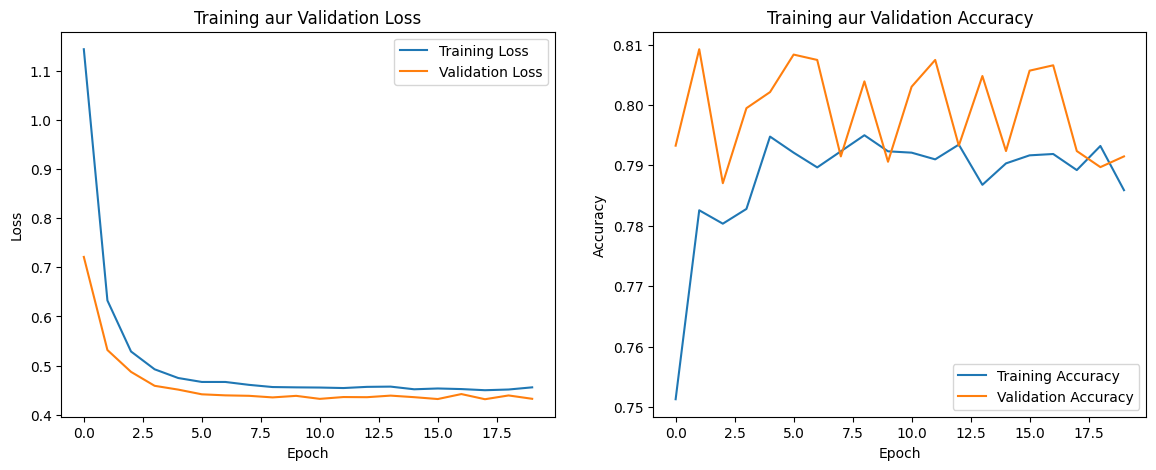

In [ ]:

# 1. Training aur Validation Loss/Accuracy ka Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training aur Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training aur Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


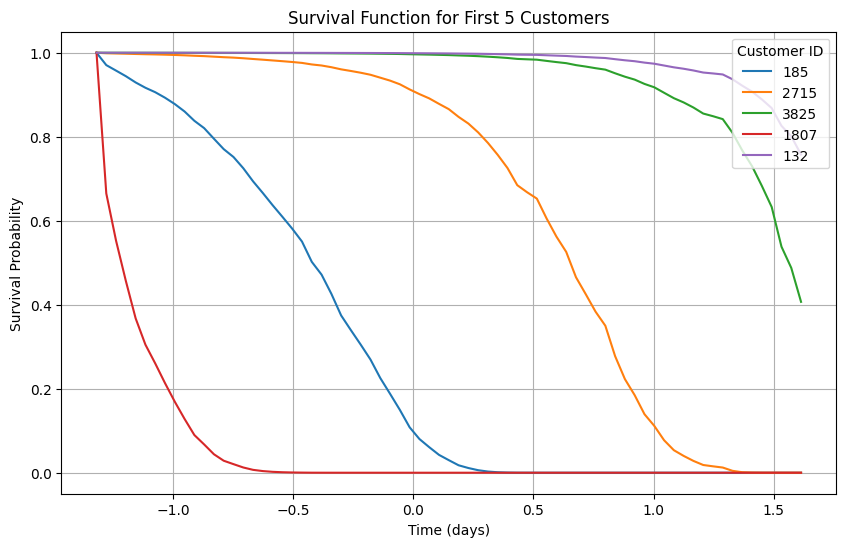

In [ ]:
# 2. Survival Function Plot
survival_function.iloc[:, :5].plot(figsize=(10, 6))
plt.title('Survival Function for First 5 Customers')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend(title='Customer ID', loc='upper right')
plt.grid(True)
plt.show()

**📝 Graph Details:**

**X-Axis (Time in Days):**

Time ko represent karta hai, yani kitne din ke baad customer ke churn hone ka risk barh raha hai.

**Y-Axis (Survival Probability):**

Survival probability woh chance hai ke customer churn nahi karega. Yeh value 1 (100%) se 0 (0%) tak hoti hai.

**Legend (Customer IDs):**

Har colored line ek specific customer ko represent kar rahi hai:

Blue (185)

Orange (2715)

Green (3825)

Red (1807)

Purple (132)

**📈 Kya Batata Hai Yeh Graph?**

**Red Line (Customer 1807):**

Yeh customer sabse jaldi churn kar gaya hai, kyunki survival probability bohat tezi se 0 hogayi.

baki ese hissab sa han

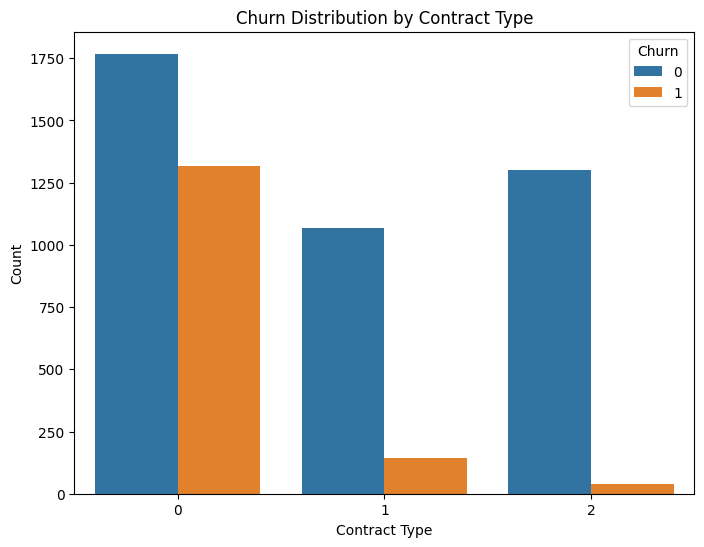

In [ ]:

# 3. Churn Distribution by Contract Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='event', data=pd.concat([x_train, y_train], axis=1))
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

**📝 Graph Key Points:**

**X-Axis (Contract Type):**

0: Month-to-Month Contract

1: One-Year Contract

2: Two-Year Contract

**Y-Axis (Count):**

Har bar ka size customers ki tadaad ko show karta hai.

**Colors (Churn Status):**

Blue (0): Customers jin ka churn nahi hua (Non-Churned).

Orange (1): Customers jin ka churn hua (Churned).

**📈 Kya Batata Hai Yeh Graph?**

**Month-to-Month Contract (0):**

Is contract type mein churn zyada hai (Orange bar kaafi bara hai).

Flexible contracts customers ke churn hone ke chances barhata hai.

**One-Year Contract (1):**

Yahan churn kaafi kam hai (Orange bar chota hai).

Long-term contracts stability provide karte hain.

**Two-Year Contract (2**):

**Yahan churn sabse kam hai.**

Customers jo long-term contracts sign karte hain, unka churn hone ka chance kaafi kam hota hai.